# Project 1

By: Charles Ciampa and Abhishek Narang

In [168]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import convolve, convolve1d
import os

In [22]:
#setup function
def load_video_frames(frames_path):
    """Load image frames from a folder and convert them to a NumPy array.

    Args:
        frames_path (str or Path): Path to the folder containing .jpg frames.

    Returns:
        np.ndarray: Array of frames with shape (N, H, W, C) as float64.
    """
    #Load image frames from a folder and convert to grayscale.
    frames_dir = Path(frames_path)
    #Get all image files and sort them 
    image_files = sorted(frames_dir.glob('*.jpg'))
    # Sort numerically 
    try:
        image_files = sorted(image_files, key=lambda x: int(''.join(filter(str.isdigit, x.stem))))
    except:
        image_files = sorted(image_files)
    
    # Imports the image -> Converts type to float -> To numpy array
    frames = np.array([cv2.imread(path).astype(np.float64) for path in image_files])
    print(f"Loaded {len(frames)} from {frames_path}")
    return frames


In [23]:
def grayscale_image(img_arr:np.ndarray, rgb_weights = [1/3, 1/3, 1/3]) -> np.ndarray:
    """Converts the image to grayscale using the given weights.

    Args:
        img_arr (np.ndarray): An array of images with last dimension being RGB.
        rgb_weights (Optional | Array): The weights [R, G, B] to convert into an grayscale image. Defaults to average [1/3, 1/3, 1/3].

    Returns:
        Array (Numpy): The image where the final dimension no longer exists and is now a grayscale value.
    """
    # Grayscale the image (T, Height, Width, RGB) -> (T, Height, Width)
    return np.dot(img_arr, rgb_weights)

In [16]:
def create_gaussian_derivative_1d(sigma):
    
    #Create 1D Gaussian derivative kernel

    kernel_size = int(2 * np.ceil(3 * sigma) + 1)
    center = kernel_size // 2
    
    x = np.arange(kernel_size) - center
    #Derivative of Gaussian: -x/(sigma^2) * exp(-x^2/(2*sigma^2))
    kernel = -x / (sigma**2) * np.exp(-x**2 / (2 * sigma**2))
    kernel = kernel / np.sum(np.abs(kernel))  #normalize
    
    return kernel

In [6]:
#temporal derivative
def compute_temporal_derivative_simple(frames, frame_idx):
    """
    Compute temporal derivative using simple [-1, 0, 1] filter.
    Returns: temporal derivative image
    """
    if frame_idx == 0 or frame_idx >= len(frames) - 1:
        return np.zeros_like(frames[frame_idx])
    
    # Simple derivative: 0.5 * (next_frame - prev_frame)
    derivative = 0.5 * (frames[frame_idx + 1] - frames[frame_idx - 1])
    
    return derivative

In [7]:
#pick threshold
def estimate_noise_std(derivatives):
    """
    Estimate standard deviation of background noise from temporal derivatives.
    Most pixels are background with small temporal changes, model them as Gaussian noise with zero mean
    Returns: Estimated standard deviation of noise
    """
    #Using median absolute deviation for robust estimation
    mad = np.median(np.abs(derivatives))
    
    #for Gaussian distribution: std = 1.4826*MAD
    std_estimate = 1.4826 * mad
    
    return std_estimate

In [8]:
#temporal derivative but gaussian 
def compute_temporal_derivative_gaussian(frames, frame_idx, t_sigma):
    
    #get temporal derivative using Gaussian derivative filter.
   
    
    kernel = create_gaussian_derivative_1d(t_sigma)
    kernel_size = len(kernel)
    half_size = kernel_size // 2
    
    #enough frames on both sides
    if frame_idx < half_size or frame_idx >= len(frames) - half_size:
        return np.zeros_like(frames[frame_idx])
    
    #apply kernel across temporal dimension
    derivative = np.zeros_like(frames[frame_idx])
    
    for i, weight in enumerate(kernel):
        offset = i - half_size
        derivative += weight * frames[frame_idx + offset]
    
    return derivative


In [9]:
def select_threshold(derivatives, n_std=3.0):
    #Select threshold based on noise statistics.
 
    noise_std = estimate_noise_std(derivatives)
    threshold = n_std * noise_std
    return threshold


In [10]:
#motion detection process
def detect_motion(frames, frame_idx, temporal_method='simple', t_sigma=1.0, 
                  threshold_method='adaptive', manual_threshold=None, n_std=3.0):
    """
    Complete motion detection pipeline for a single frame.
    Args: frames: List of video frames, frame_idx: Index of frame to process
        temporal_method: 'simple' or 'gaussian', t_sigma: Temporal Gaussian std dev (if using gaussian)
        threshold_method: 'adaptive' or 'manual', manual_threshold: Manual threshold value
        n_std: Number of std devs for adaptive threshold
    Returns: Dictionary with results
    """
    #1- Compute temporal derivative
    if temporal_method == 'simple':
        derivative = compute_temporal_derivative_simple(frames, frame_idx)
    elif temporal_method == 'gaussian':
        derivative = compute_temporal_derivative_gaussian(frames, frame_idx, t_sigma)
    else:
        raise ValueError(f"Unknown temporal method: {temporal_method}")
    
    #2- Compute absolute value
    abs_derivative = np.abs(derivative)
    
    #3- Select threshold
    if threshold_method == 'adaptive':
        threshold = select_threshold(abs_derivative, n_std)
    else:
        threshold = manual_threshold
    
    #4-Create binary mask
    mask = (abs_derivative > threshold).astype(np.uint8)
    
    #5- Overlay mask on original frame
    result_frame = frames[frame_idx].copy()
    overlay = np.stack([result_frame, result_frame, result_frame], axis=2)
    overlay[:, :, 0] = np.maximum(overlay[:, :, 0], mask.astype(np.float32))
    
    return {
        'derivative': derivative,
        'abs_derivative': abs_derivative,
        'threshold': threshold,
        'mask': mask,
        'overlay': overlay,
        'noise_std': estimate_noise_std(abs_derivative)
    }


In [11]:
#the 15pt part, temporal derivative filter
def experiment_temporal_filters(frames, frame_idx):
    
    #Compare simple and Gaussian temporal derivative filters - 3 values of sigma
    
    
    #Test parameters-3 different t_sigma values
    t_sigmas = [0.5, 1.0, 2.0]
    fig, axes = plt.subplots(2, len(t_sigmas) + 1, figsize=(16, 8))
    
    #Simple filter: 0.5[-1, 0, 1]
    result_simple = detect_motion(frames, frame_idx, temporal_method='simple')
    
    axes[0, 0].imshow(result_simple['abs_derivative'], cmap='hot')
    axes[0, 0].set_title('Simple Filter\n[-1, 0, 1]')
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(result_simple['mask'], cmap='gray')
    axes[1, 0].set_title(f"Mask (t={result_simple['threshold']:.4f})")
    axes[1, 0].axis('off')
    print(f"\n\n--------")

    print(f"Temporal derivative filter- frame: "+ str(frame_idx))
    print(f"\nSimple Filter:")
    print(f"   Threshold: {result_simple['threshold']:.4f}")
    print(f"   Noise std: {result_simple['noise_std']:.4f}")
    print(f"   Motion pixels: {np.sum(result_simple['mask'])} ({100*np.mean(result_simple['mask']):.2f}%)")
    
    #Gaussian filters with diff sigma values
    for i, t_sigma in enumerate(t_sigmas): #1.0 and 2.0
        result = detect_motion(frames, frame_idx, 
                              temporal_method='gaussian', t_sigma=t_sigma)
        
        axes[0, i+1].imshow(result['abs_derivative'], cmap='hot')
        axes[0, i+1].set_title(f'Gaussian Derivative\nσ_t={t_sigma}')
        axes[0, i+1].axis('off')
        
        axes[1, i+1].imshow(result['mask'], cmap='gray')
        axes[1, i+1].set_title(f"Mask (t={result['threshold']:.4f})")
        axes[1, i+1].axis('off')
        
        print(f"Gaussian Filter (σ_t={t_sigma}):")
        print(f"  Threshold: {result['threshold']:.4f}")
        print(f"  Noise std: {result['noise_std']:.4f}")
        print(f"  Motion pixels: {np.sum(result['mask'])} ({100*np.mean(result['mask']):.2f}%)")
    
    plt.tight_layout()
    plt.savefig('temporal_filters_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [85]:
def apply_temporal_kernel(img_arr, kernel, axis=0, **args):
    """Applies a 1D kernel along the temporal axis of the image array.

    Args:
        img_arr (np.ndarray): Numpy array (T, H, W) representing video frames.
        kernel (array-like): 1D kernel to convolve along the specified axis.
        axis (int, optional): Axis along which to apply the kernel. Defaults to 0 (temporal).
        **args: Additional keyword arguments passed to scipy.ndimage.convolve1d.

    Returns:
        np.ndarray: The filtered array with the same shape as img_arr.
    """
    return convolve1d(img_arr, kernel, axis=axis, **args)

In [86]:
def apply_img_kernel(img_arr, kernel, axes=(1,2), **args):
    """Applys a kernel to the image.

    Args:
        img_arr (numpy): Numpy array (T, H, W)
        kernel (numpy): (NXN) Kernel which to apply over the images

    Returns:
        numpy: The image post filter
    """    
    return convolve(img_arr, kernel, axes=axes, **args)

## Red Chair Images

In [94]:
# Import the images
red_chair_imgs_rgb = load_video_frames("data/RedChair")
# Convert RGB to Grayscale
red_chair_imgs_bw = grayscale_image(red_chair_imgs_rgb)

Loaded 353 from data/RedChair


In [95]:
box_filter_3x3 = np.ones((3,3)) / 9
box_filter_5x5 = np.ones((5,5)) / 25

kernel_3x3_1d = cv2.getGaussianKernel(3, 0)  # size=3, sigma=0 (auto-calculated)
gaussian_3x3 =kernel_3x3_1d * kernel_3x3_1d.T

kernel_5x5_1d = cv2.getGaussianKernel(5, 0)

# Convert to 2D by outer product
gaussian_5x5 = kernel_5x5_1d * kernel_5x5_1d.T


In [96]:
simple_temporal_kernel = np.array([-1, 0, 1]) / 2
gaussian_0_termporal_kernel = create_gaussian_derivative_1d(0.5)
gaussian_1_termporal_kernel = create_gaussian_derivative_1d(1.0)
gaussian_2_termporal_kernel = create_gaussian_derivative_1d(2.0)

In [164]:
blur_box = apply_img_kernel(red_chair_imgs_bw, kernel_5x5_1d)
blur_box_gradient = apply_temporal_kernel(blur_box, simple_temporal_kernel)

mask = (np.abs(blur_box_gradient) > 1.2).astype(np.float32)

In [165]:
masked_imgs = (red_chair_imgs_rgb * mask[..., np.newaxis])

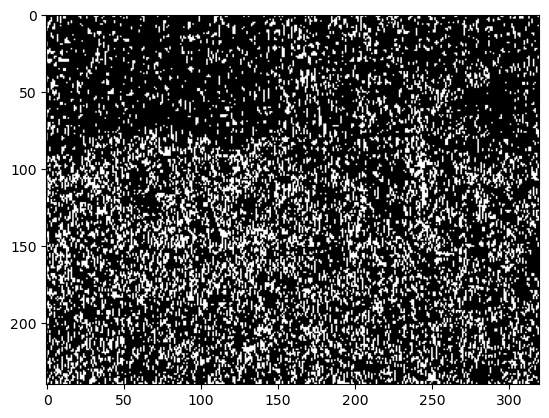

In [166]:
plt.imshow(mask[100], cmap='gray')
plt.show()

In [173]:
out_path = "test.mp4"
if os.path.exists(out_path):
    os.remove(out_path)

T, H, W, C = masked_imgs.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('test.mp4', fourcc, 30, (W, H))

for frame in masked_imgs.astype(np.uint8):
    out.write(frame)

out.release()

Motion detection using temporal derivative
Loaded 485 from data/EnterExitCrossingPaths2cor

frame 50
  motion detected: 5.14%

frame 100
  motion detected: 3.97%

frame 150
  motion detected: 2.66%

frame 200
  motion detected: 5.14%

frame 250
  motion detected: 2.29%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.49999999999999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..126.59595762336194].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..115.70100215971874].




--------
Temporal derivative filter- frame: 50

Simple Filter:
   Threshold: 6.6717
   Noise std: 2.2239
   Motion pixels: 17043 (5.14%)
Gaussian Filter (σ_t=0.5):
  Threshold: 6.6498
  Noise std: 2.2166
  Motion pixels: 17057 (5.14%)
Gaussian Filter (σ_t=1.0):
  Threshold: 5.3459
  Noise std: 1.7820
  Motion pixels: 21196 (6.39%)
Gaussian Filter (σ_t=2.0):
  Threshold: 3.8150
  Noise std: 1.2717
  Motion pixels: 29999 (9.04%)


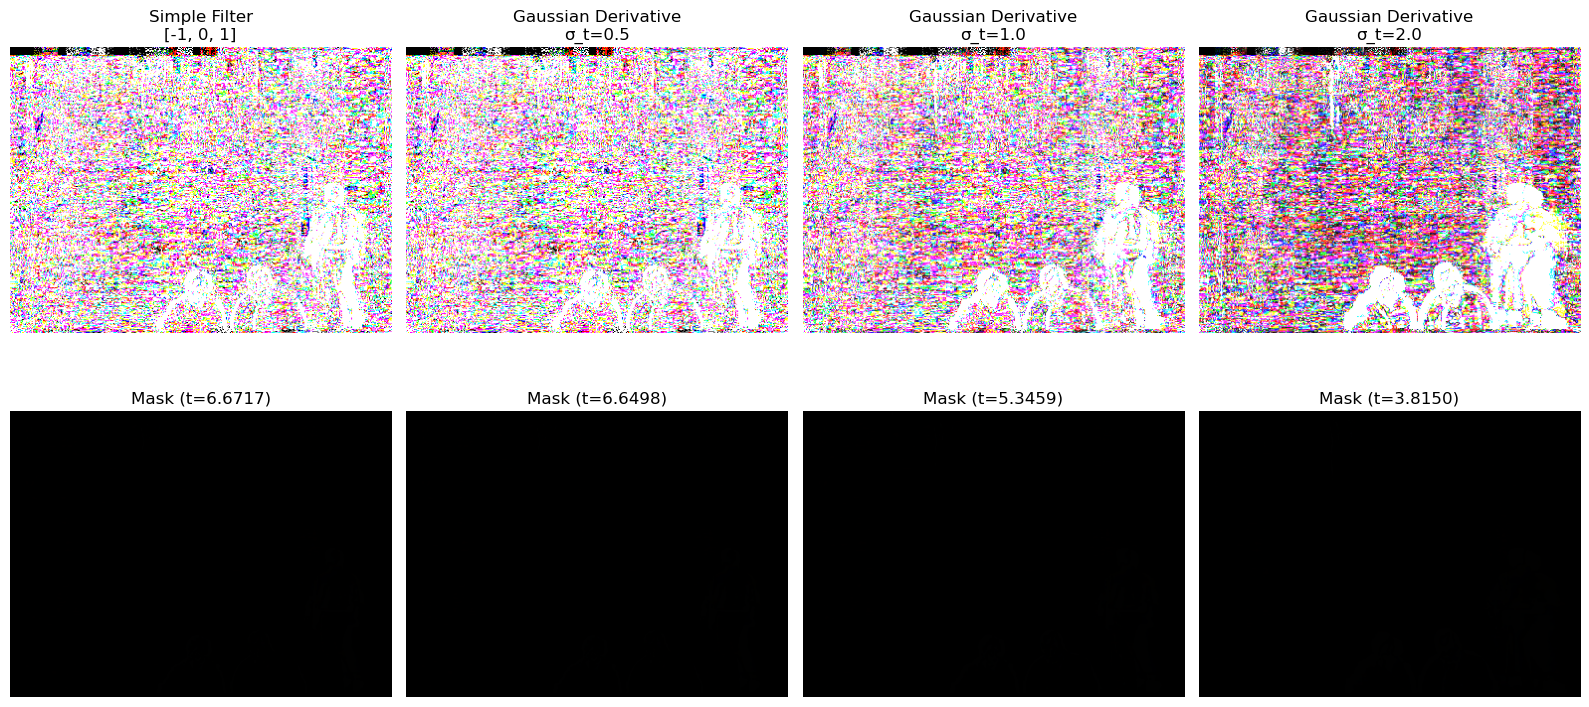

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.49999999999999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..126.96259400284875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..116.58712013558154].




--------
Temporal derivative filter- frame: 100

Simple Filter:
   Threshold: 6.6717
   Noise std: 2.2239
   Motion pixels: 13178 (3.97%)
Gaussian Filter (σ_t=0.5):
  Threshold: 6.6278
  Noise std: 2.2093
  Motion pixels: 13195 (3.98%)
Gaussian Filter (σ_t=1.0):
  Threshold: 4.7662
  Noise std: 1.5887
  Motion pixels: 17119 (5.16%)
Gaussian Filter (σ_t=2.0):
  Threshold: 3.6201
  Noise std: 1.2067
  Motion pixels: 22480 (6.78%)


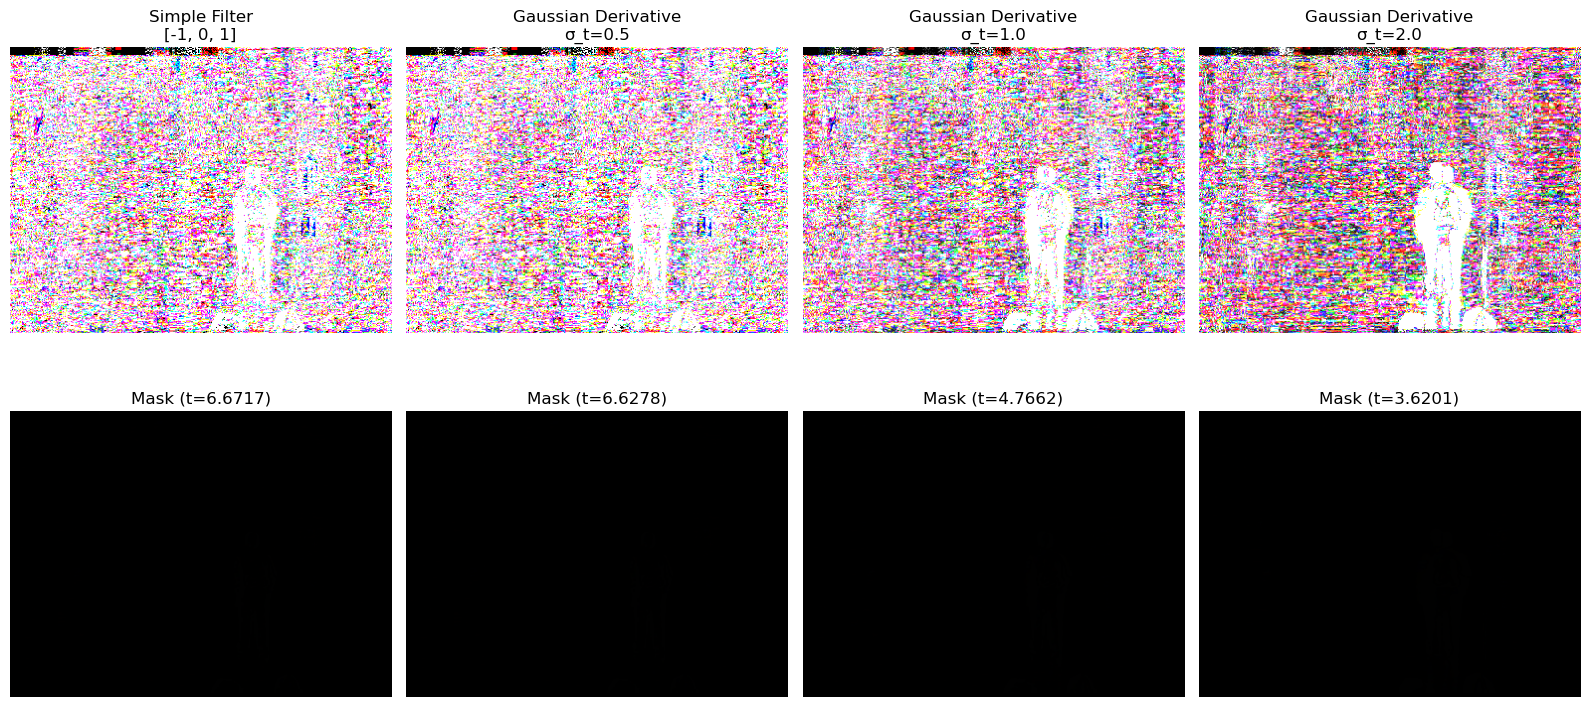

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..126.88090238278919].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..125.832261096773].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..116.58492808043196].




--------
Temporal derivative filter- frame: 150

Simple Filter:
   Threshold: 6.6717
   Noise std: 2.2239
   Motion pixels: 8818 (2.66%)
Gaussian Filter (σ_t=0.5):
  Threshold: 6.6059
  Noise std: 2.2020
  Motion pixels: 8851 (2.67%)
Gaussian Filter (σ_t=1.0):
  Threshold: 5.1867
  Noise std: 1.7289
  Motion pixels: 12439 (3.75%)
Gaussian Filter (σ_t=2.0):
  Threshold: 4.3159
  Noise std: 1.4386
  Motion pixels: 16556 (4.99%)


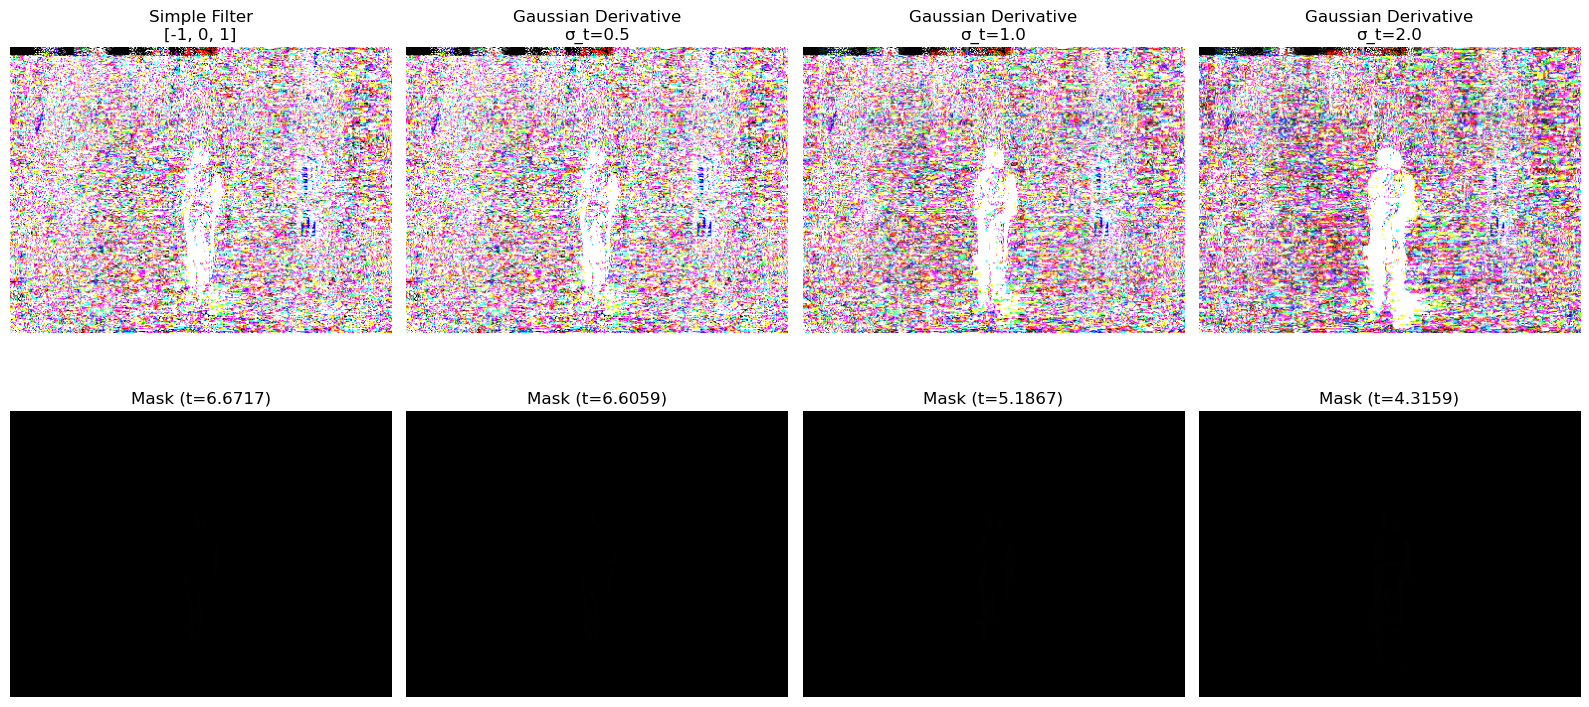

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.49999999999999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..126.28119325903418].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..115.89927646940988].




--------
Temporal derivative filter- frame: 200

Simple Filter:
   Threshold: 6.6717
   Noise std: 2.2239
   Motion pixels: 17044 (5.14%)
Gaussian Filter (σ_t=0.5):
  Threshold: 6.6498
  Noise std: 2.2166
  Motion pixels: 17073 (5.15%)
Gaussian Filter (σ_t=1.0):
  Threshold: 5.3737
  Noise std: 1.7912
  Motion pixels: 22934 (6.91%)
Gaussian Filter (σ_t=2.0):
  Threshold: 4.4505
  Noise std: 1.4835
  Motion pixels: 35173 (10.60%)


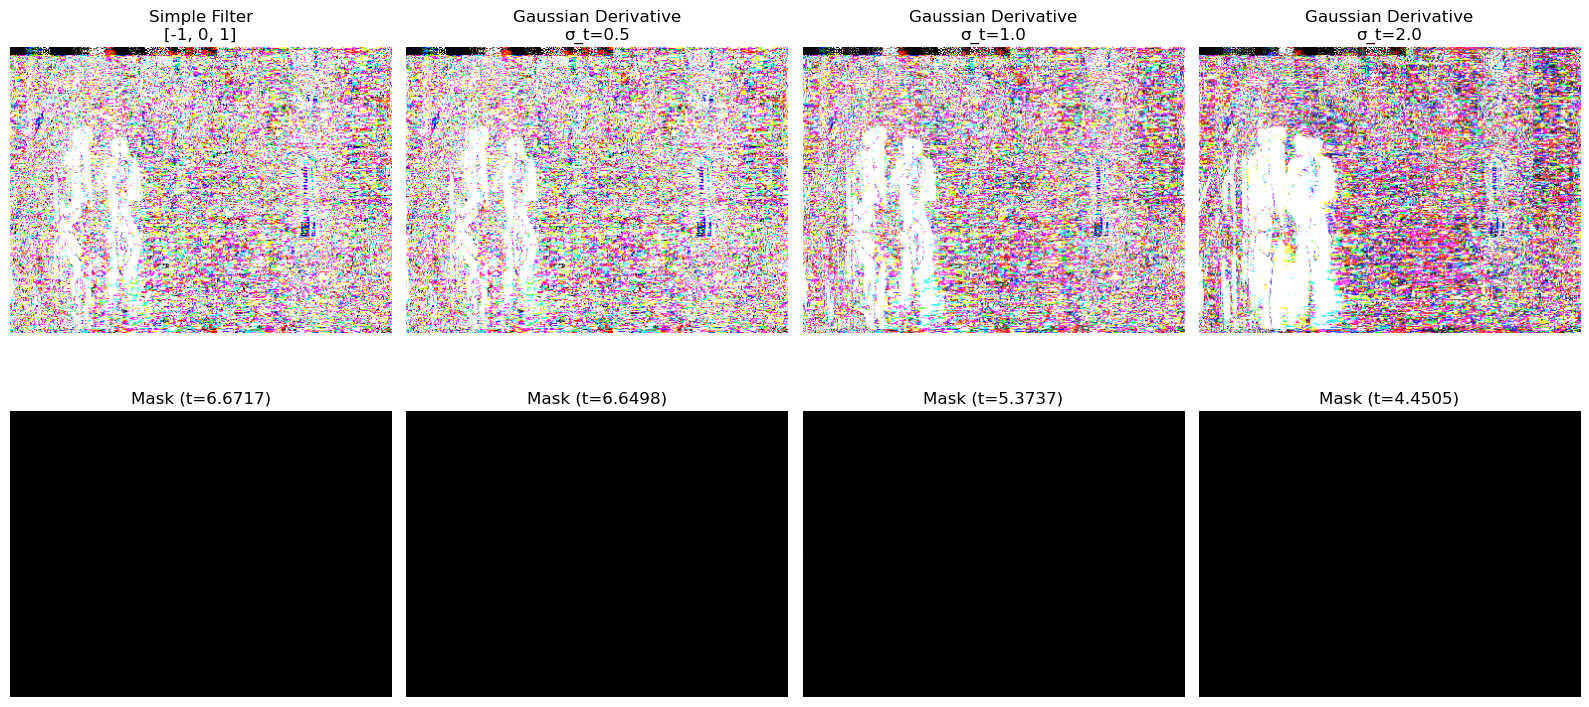

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..126.99999999999999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..126.963398180269].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..116.84069155728967].




--------
Temporal derivative filter- frame: 250

Simple Filter:
   Threshold: 6.6717
   Noise std: 2.2239
   Motion pixels: 7584 (2.29%)
Gaussian Filter (σ_t=0.5):
  Threshold: 6.6168
  Noise std: 2.2056
  Motion pixels: 7607 (2.29%)
Gaussian Filter (σ_t=1.0):
  Threshold: 5.1017
  Noise std: 1.7006
  Motion pixels: 10892 (3.28%)
Gaussian Filter (σ_t=2.0):
  Threshold: 3.9232
  Noise std: 1.3077
  Motion pixels: 14706 (4.43%)


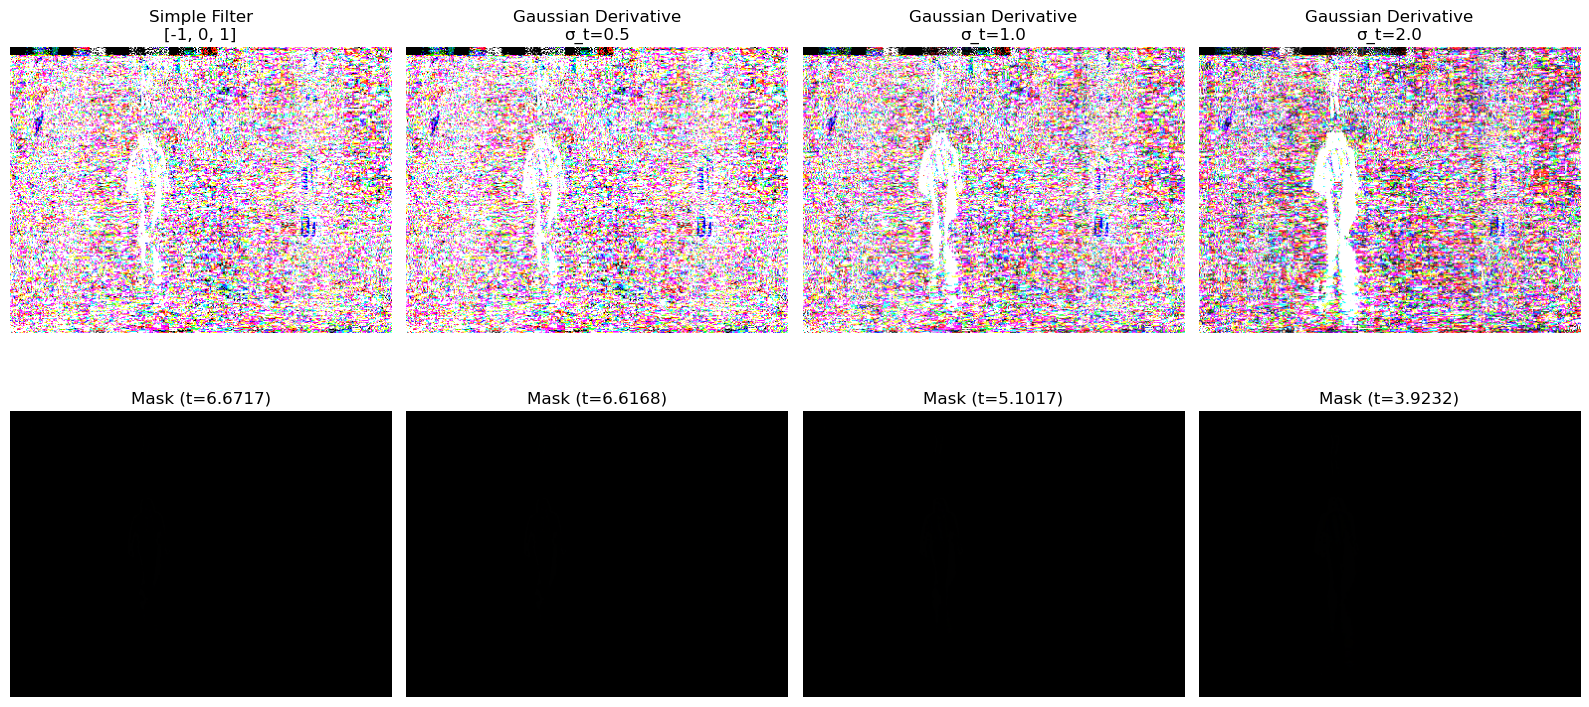

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..127.5].



2-Compute temporal derivative
3-Thresholding (threshold = 6.6717)
4-Combining mask with original frame


TypeError: Invalid shape (288, 384, 3, 3) for image data

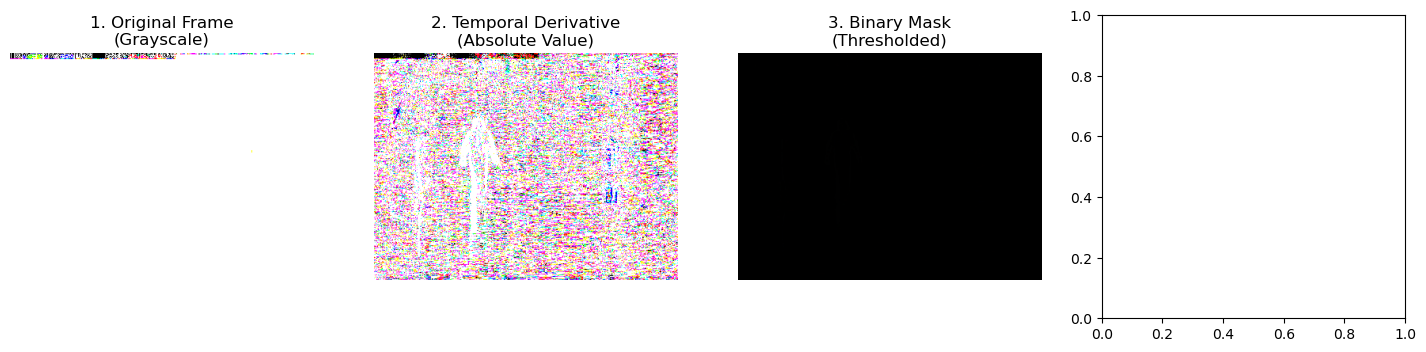

In [ ]:
print("Motion detection using temporal derivative")
frames_path = "data/EnterExitCrossingPaths2cor"  

test_frame_indices = [50, 100, 150, 200, 250]
for idx in test_frame_indices:
        print(f"\nframe {idx}")
        result = detect_motion(frames, idx, temporal_method='simple')
        print(f"  motion detected: {100*np.mean(result['mask']):.2f}%")

#Run temporal filters experiment 
for idx in test_frame_indices:
    experiment_temporal_filters(frames, idx)

#middle frame for basic outline demonstration
demo_frame_idx = len(frames) // 2

#2 Apply temporal derivative
print("\n2-Compute temporal derivative")
result = detect_motion(frames, demo_frame_idx, temporal_method='simple')

# 3/4 Threshold and combine with original
print(f"3-Thresholding (threshold = {result['threshold']:.4f})")
print(f"4-Combining mask with original frame")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(frames[demo_frame_idx], cmap='gray')
axes[0].set_title('1. Original Frame\n(Grayscale)')
axes[0].axis('off')

axes[1].imshow(result['abs_derivative'], cmap='hot')
axes[1].set_title('2. Temporal Derivative\n(Absolute Value)')
axes[1].axis('off')

axes[2].imshow(result['mask'], cmap='gray')
axes[2].set_title('3. Binary Mask\n(Thresholded)')
axes[2].axis('off')

axes[3].imshow(result['overlay'])
axes[3].set_title('4. Final Result\n(Mask + Original)')
axes[3].axis('off')

plt.tight_layout()
plt.savefig('basic_outline_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResults summary:")
print(f"  Estimated noise std: {result['noise_std']:.4f}")
print(f"  Adaptive threshold: {result['threshold']:.4f}")
print(f"  Detected motion pixels: {np.sum(result['mask'])} ({100*np.mean(result['mask']):.2f}%)")

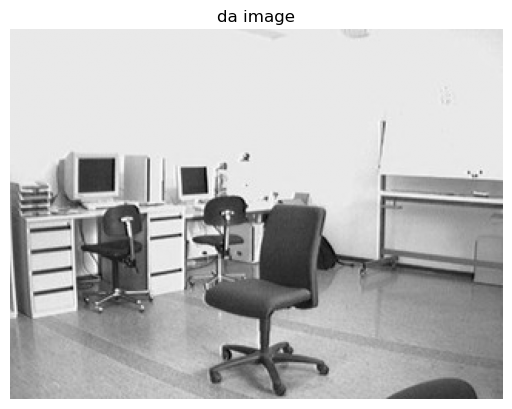

In [26]:
plt.imshow(imgs[200], cmap='gray')
plt.title("da image")
plt.axis('off') # Optional: hides the axis labels
plt.show()

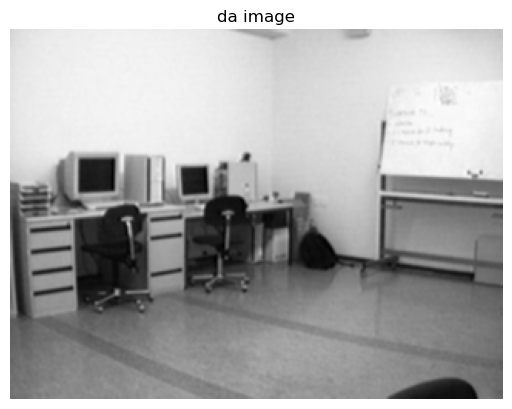

In [130]:
plt.imshow(img_filtered, cmap='gray')
plt.title("da image")
plt.axis('off') # Optional: hides the axis labels
plt.show()